# 05 Plot Resolution Results

This notebook is the single plotting entry point for the resolution-degradation workflow.
Run the build stages in the terminal first, then use the cells below to load saved maps and catalogs and make plots interactively.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

ROOT = Path.cwd().resolve()
if not (ROOT / 'm33_pipeline').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from m33_pipeline.io import read_catalog, read_fits_data
from m33_pipeline.reporting import add_fit_values, write_latex_commands
from m33_pipeline.resolution_degradation import (
    DEFAULT_DISTANCES_MPC,
    FIELDS,
    PIXEL_SCALE_ARCSEC,
    boundary_map_path,
    degraded_flux_path,
    degraded_scale_factor,
    distance_tag,
    ensure_resolution_dirs,
    m33_pixel_scale_pc,
    peaks_catalog_path,
    total_catalog_path,
    zoi_map_path,
)

stage_paths = ensure_resolution_dirs()
plt.rcParams['figure.dpi'] = 300

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True


In [3]:
distances_mpc = DEFAULT_DISTANCES_MPC
fields = FIELDS
plot_fields = tuple(f for f in fields if f != 'F6')
example_field = 'NW'
example_distance_mpc = 20.0
save_figures = True

print('Distance included:', distances_mpc)
print('Fields being included:', plot_fields)

resolution_fit_results = {}


Distance included: (0.84, 5.0, 10.0, 20.0, 35.0, 50.0, 100.0)
Fields being included: ('NW', 'NE', 'SW', 'SE', 'F5', 'F7', 'F8', 'F9')


In [4]:
def field_suffix(include_fields=None):
    if not include_fields:
        return ''
    return '__fields_' + '_'.join(include_fields)


def filter_catalog_by_fields(df, include_fields=None):
    if include_fields is None or df.empty or 'field' not in df.columns:
        return df.copy()
    return df[df['field'].isin(include_fields)].copy()


def weighted_linear_fit(x, y, yerr=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if yerr is None:
        yerr = np.ones_like(y, dtype=float)
    else:
        yerr = np.asarray(yerr, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    if mask.sum() < 3:
        return None
    x_fit = x[mask]
    y_fit = y[mask]
    yerr_fit = yerr[mask]
    design = np.column_stack([x_fit, np.ones_like(x_fit)])
    weights = 1.0 / np.square(yerr_fit)
    xtwx = design.T @ (weights[:, None] * design)
    xtwy = design.T @ (weights * y_fit)
    try:
        beta = np.linalg.solve(xtwx, xtwy)
        cov = np.linalg.inv(xtwx)
    except np.linalg.LinAlgError:
        return None
    slope = float(beta[0])
    intercept = float(beta[1])
    resid = y_fit - (slope * x_fit + intercept)
    dof = max(mask.sum() - 2, 1)
    chi2_red = float(np.sum((resid / yerr_fit) ** 2) / dof)
    cov = cov * max(chi2_red, 1.0)
    return {
        'slope': slope,
        'intercept': intercept,
        'slope_stderr': float(np.sqrt(max(cov[0, 0], 0.0))),
        'intercept_stderr': float(np.sqrt(max(cov[1, 1], 0.0))),
        'n_points': int(mask.sum()),
        'chi2_red': chi2_red,
        'cov': cov,
        'mask': mask,
    }


def fit_loglog_relation(x, y, yerr=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if yerr is None:
        yerr = np.ones_like(y, dtype=float)
    else:
        yerr = np.asarray(yerr, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (x > 0) & (y > 0) & (yerr > 0)
    if mask.sum() < 3:
        return None
    logx = np.log10(x[mask])
    logy = np.log10(y[mask])
    sigma_logy = yerr[mask] / (y[mask] * np.log(10.0))
    finite_sigma = np.isfinite(sigma_logy) & (sigma_logy > 0)
    if finite_sigma.sum() == 0:
        return None
    sigma_floor = np.nanmedian(sigma_logy[finite_sigma])
    sigma_logy = np.where(finite_sigma, sigma_logy, sigma_floor)
    good = np.isfinite(logx) & np.isfinite(logy) & np.isfinite(sigma_logy) & (sigma_logy > 0)
    if good.sum() < 3:
        return None
    fit = weighted_linear_fit(logx[good], logy[good], sigma_logy[good])
    if fit is None:
        return None
    fit_mask = np.zeros_like(mask, dtype=bool)
    mask_indices = np.flatnonzero(mask)
    fit_mask[mask_indices[good]] = True
    fit['mask'] = fit_mask
    fit['space'] = 'loglog'
    return fit


def fit_linear_relation(x, y, yerr=None):
    return weighted_linear_fit(x, y, yerr=yerr)


def fit_band_linear(xfit, fit):
    slope = fit['slope']
    intercept = fit['intercept']
    cov = np.asarray(fit['cov'], dtype=float)
    yfit = slope * xfit + intercept
    design = np.column_stack([xfit, np.ones_like(xfit)])
    yvar = np.einsum('ij,jk,ik->i', design, cov, design)
    ysig = np.sqrt(np.maximum(yvar, 0.0))
    return yfit, yfit - ysig, yfit + ysig


def fit_band_loglog(xfit, fit):
    logxfit = np.log10(xfit)
    logyfit, logylo, logyhi = fit_band_linear(logxfit, fit)
    return np.power(10.0, logyfit), np.power(10.0, logylo), np.power(10.0, logyhi)


def plot_fit_with_band(ax, xfit, yfit, ylo, yhi, color, label=None):
    # ax.fill_between(xfit, ylo, yhi, color=color, alpha=0.15, linewidth=0)
    ax.plot(xfit, yfit, color='black', linewidth=3.0, alpha=0.95, zorder=4)
    ax.plot(xfit, yfit, color=color, linewidth=2.0, alpha=1.0, zorder=5, label=label)


def get_density_fit_mask(y, max_density_cm3=300.0, percentile_clip=95.0):
    y = np.asarray(y, dtype=float)
    finite = y[np.isfinite(y) & (y > 0)]
    if finite.size < 3:
        return np.isfinite(y) & (y > 0)
    clip_value = min(max_density_cm3, np.nanpercentile(finite, percentile_clip))
    return np.isfinite(y) & (y > 0) & (y <= clip_value)


def metallicity_indicator_error(df):
    if 'metallicity_indicator_e' in df.columns:
        return df['metallicity_indicator_e'].to_numpy(dtype=float)
    if 'Z_O3N2_M2013_e' in df.columns:
        return df['Z_O3N2_M2013_e'].to_numpy(dtype=float)
    if 'O3N2_e' in df.columns:
        return 0.214 * df['O3N2_e'].to_numpy(dtype=float)
    return np.full(len(df), np.nan, dtype=float)


def radial_property_errors(df, column):
    if column == 'logU_KK04' and 'logU_KK04_e' in df.columns:
        return df['logU_KK04_e'].to_numpy(dtype=float)
    if column == 'ne_SII_cm3':
        if 'ne_SII_cm3_e' in df.columns:
            return df['ne_SII_cm3_e'].to_numpy(dtype=float)
        if 'ne_SII_cm3_mc_minus' in df.columns and 'ne_SII_cm3_mc_plus' in df.columns:
            lo = np.abs(df['ne_SII_cm3_mc_minus'].to_numpy(dtype=float))
            hi = np.abs(df['ne_SII_cm3_mc_plus'].to_numpy(dtype=float))
            return 0.5 * (lo + hi)
    if column == 'metallicity_indicator':
        return metallicity_indicator_error(df)
    return np.full(len(df), np.nan, dtype=float)


def flux_to_luminosity(flux, distance_mpc):
    flux = np.asarray(flux, dtype=float)
    distance_mpc = np.asarray(distance_mpc, dtype=float)
    mpc_to_cm = 3.085677581e24
    d_cm = distance_mpc * mpc_to_cm
    return 4.0 * np.pi * np.square(d_cm) * flux


def load_catalogs_by_distance(distances_mpc=distances_mpc, include_fields=None):
    catalogs = {}
    for distance_mpc in distances_mpc:
        path = total_catalog_path(distance_mpc, stage_paths)
        if not path.exists():
            continue
        df = read_catalog(path)
        catalogs[distance_mpc] = filter_catalog_by_fields(df, include_fields)
    return catalogs


def map_norm(image):
    finite = image[np.isfinite(image) & (image > 0)]
    if finite.size == 0:
        return None
    vmin = np.nanpercentile(finite, 5)
    vmax = np.nanpercentile(finite, 99.5)
    return LogNorm(vmin=max(vmin, np.nextafter(0, 1)), vmax=max(vmax, vmin * 1.01))


def plot_peak_subplots_for_field(field, distances_mpc=distances_mpc, save=False):
    ncols = 3
    nrows = int(np.ceil(len(distances_mpc) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, distance_mpc in zip(axes, distances_mpc):
        flux_map = read_fits_data(degraded_flux_path(field, 'Halpha', distance_mpc, stage_paths))
        peaks_df = read_catalog(peaks_catalog_path(field, distance_mpc, stage_paths))
        ax.imshow(flux_map, origin='lower', cmap='rainbow', norm=map_norm(flux_map))
        if not peaks_df.empty:
            ax.scatter(peaks_df['x'], peaks_df['y'], s=12, facecolors='white', edgecolors='black', linewidths=0.7)
        pix_pc = m33_pixel_scale_pc(PIXEL_SCALE_ARCSEC / degraded_scale_factor(distance_mpc))
        ax.text(0.03, 0.97, f'{distance_tag(distance_mpc)} Mpc\n{pix_pc:.1f} pc/pix\nN={len(peaks_df)}',
                transform=ax.transAxes, ha='left', va='top', fontsize=14,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
        # ax.set_title(field)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(4)
            if np.isclose(distance_mpc, 50) or np.isclose(distance_mpc, 100):
                spine.set_color("red")
            else:
                spine.set_color("black")  
    for ax in axes[len(distances_mpc):]:
        ax.axis('off')
    
    plt.tight_layout()
    if save:
        fig.savefig(stage_paths.plots_dir / f'{field}_peak_subplots.png', dpi=200)
    return fig


def plot_boundary_subplots_for_field(field, distances_mpc=distances_mpc, save=False):
    ncols = 3
    nrows = int(np.ceil(len(distances_mpc) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    contour_color = plt.cm.rainbow(0.95)
    for ax, distance_mpc in zip(axes, distances_mpc):
        image = read_fits_data(degraded_flux_path(field, 'Halpha', distance_mpc, stage_paths))
        boundary = read_fits_data(boundary_map_path(field, distance_mpc, stage_paths))
        ax.imshow(image, origin='lower', cmap='rainbow', norm=map_norm(image))
        ax.contour(boundary > 0, levels=[0.5], colors=[contour_color], linewidths=0.6)
        pix_pc = m33_pixel_scale_pc(PIXEL_SCALE_ARCSEC / degraded_scale_factor(distance_mpc))
        n_regions = int(np.unique(boundary[boundary > 0]).size)
        ax.text(0.03, 0.97, f'{distance_tag(distance_mpc)} Mpc\n{pix_pc:.1f} pc/pix\nN={n_regions}',
                transform=ax.transAxes, ha='left', va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
        ax.set_title(field)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[len(distances_mpc):]:
        ax.axis('off')
    plt.tight_layout()
    if save:
        fig.savefig(stage_paths.plots_dir / f'{field}_boundary_subplots.png', dpi=200)
    return fig


def plot_zoi_boundary_subplots_for_field(field, distances_mpc=distances_mpc, save=False):
    ncols = 3
    nrows = int(np.ceil(len(distances_mpc) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    contour_color = 'black'
    for ax, distance_mpc in zip(axes, distances_mpc):
        zoi = read_fits_data(zoi_map_path(field, distance_mpc, stage_paths))
        boundary = read_fits_data(boundary_map_path(field, distance_mpc, stage_paths))
        zoi_show = np.where(zoi > 0, zoi, np.nan)
        ax.imshow(zoi_show, origin='lower', cmap='rainbow')
        ax.contour(boundary > 0, levels=[0.5], colors=[contour_color], linewidths=0.7)
        ax.set_title(f'{field} {distance_tag(distance_mpc)} Mpc')
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[len(distances_mpc):]:
        ax.axis('off')
    plt.tight_layout()
    if save:
        fig.savefig(stage_paths.plots_dir / f'{field}_zoi_boundary_subplots.png', dpi=200)
    return fig


def plot_luminosity_vs_radius(catalogs_by_distance, include_fields=None, save=False):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(catalogs_by_distance)))
    for color, (distance_mpc, df) in zip(colors, sorted(catalogs_by_distance.items())):
        df = filter_catalog_by_fields(df, include_fields)
        if df.empty:
            continue
        radius_col = 'radius_pc_eq_effective' if 'radius_pc_eq_effective' in df.columns else 'radius_pc_eq'
        x = df[radius_col].to_numpy(dtype=float)
        y = df['L_Ha_sum_dered'].to_numpy(dtype=float)
        yerr = np.full(len(df), np.nan, dtype=float)
        if 'F_Halpha_e_sum_dered' in df.columns:
            yerr = flux_to_luminosity(df['F_Halpha_e_sum_dered'].to_numpy(dtype=float), df['distance_mpc'].to_numpy(dtype=float))
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        if mask.sum() == 0:
            continue
        ax.scatter(x[mask], y[mask], s=18, facecolors='none', edgecolors=color, linewidths=0.9, alpha=0.35, label=f'{distance_tag(distance_mpc)} Mpc')
        fit = fit_loglog_relation(x, y, yerr=yerr)
        if fit is not None:
            resolution_fit_results[f'luminosityRadiusD{resolution_command_token(distance_mpc)}Mpc'] = fit
            fit_mask = fit['mask']
            xfit = np.geomspace(np.nanmin(x[fit_mask]), np.nanmax(x[fit_mask]), 200)
            yfit, ylo, yhi = fit_band_loglog(xfit, fit)
            plot_fit_with_band(ax, xfit, yfit, ylo, yhi, color)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Region radius (pc)')
    ax.set_ylabel(r'$L_{\rm H\alpha}$ (erg/s)')
    ax.legend(frameon=False, fontsize=14)
    plt.tight_layout()
    if save:
        fig.savefig(stage_paths.plots_dir / f'luminosity_vs_radius_all_distances{field_suffix(include_fields)}.png', dpi=200)
    return fig


def plot_radial_gradients(catalogs_by_distance, include_fields=None, save=False):
    properties = [
        ('logU_KK04', r'$\log U$', 'logU_vs_rgal_all_distances'),
        ('ne_SII_cm3', r'$n_e$ [cm$^{-3}$]', 'density_vs_rgal_all_distances'),
        ('metallicity_indicator', r'$12+\log({\rm O/H})$', 'metallicity_vs_rgal_all_distances'),
    ]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(catalogs_by_distance)))
    figs = []
    for column, ylabel, stem in properties:
        fig, ax = plt.subplots(figsize=(8, 6))
        for color, (distance_mpc, df) in zip(colors, sorted(catalogs_by_distance.items())):
            df = filter_catalog_by_fields(df, include_fields)
            if df.empty or column not in df.columns:
                continue
            x = df['r_gal_kpc'].to_numpy(dtype=float)
            y = df[column].to_numpy(dtype=float)
            yerr = radial_property_errors(df, column)
            mask = np.isfinite(x) & np.isfinite(y)
            if column == 'ne_SII_cm3':
                mask &= y > 0
            if mask.sum() == 0:
                continue
            ax.scatter(x[mask], y[mask], s=16, facecolors='none', edgecolors=color, linewidths=0.9, alpha=0.35, label=f'{distance_tag(distance_mpc)} Mpc')
            if column == 'ne_SII_cm3':
                fit_mask = mask & get_density_fit_mask(y)
                yfit_values = np.log10(y[fit_mask]) if fit_mask.sum() >= 3 else np.array([])
                yerr_fit = np.where(np.isfinite(yerr[fit_mask]) & (yerr[fit_mask] > 0), yerr[fit_mask] / (y[fit_mask] * np.log(10.0)), np.nan) if fit_mask.sum() >= 3 else np.array([])
                finite_err = np.isfinite(yerr_fit) & (yerr_fit > 0)
                if finite_err.sum() >= 3:
                    fit = fit_linear_relation(x[fit_mask][finite_err], yfit_values[finite_err], yerr=yerr_fit[finite_err])
                else:
                    fit = fit_linear_relation(x[fit_mask], yfit_values, yerr=None) if fit_mask.sum() >= 3 else None
                if fit is not None:
                    resolution_fit_results[f'radialDensityD{resolution_command_token(distance_mpc)}Mpc'] = fit
                    xfit = np.linspace(np.nanmin(x[fit_mask]), np.nanmax(x[fit_mask]), 200)
                    logyfit, logylo, logyhi = fit_band_linear(xfit, fit)
                    plot_fit_with_band(ax, xfit, np.power(10.0, logyfit), np.power(10.0, logylo), np.power(10.0, logyhi), color)
            else:
                fit = fit_linear_relation(x[mask], y[mask], yerr=yerr[mask] if np.isfinite(yerr[mask]).sum() >= 3 else None)
                if fit is not None:
                    fit_prefix = {'logU_KK04': 'radialLogU', 'metallicity_indicator': 'radialMetallicity'}[column]
                    resolution_fit_results[f'{fit_prefix}D{resolution_command_token(distance_mpc)}Mpc'] = fit
                    xfit = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 200)
                    yfit, ylo, yhi = fit_band_linear(xfit, fit)
                    plot_fit_with_band(ax, xfit, yfit, ylo, yhi, color)
        if column == 'ne_SII_cm3':
            ax.set_yscale('log')
        if column == 'logU_KK04':
            ax.set_ylim(-4, -2.5)
        if column == 'metallicity_indicator':
            ax.set_ylim(8, 9)
        ax.set_xlabel('Galactocentric radius (kpc)')
        ax.set_ylabel(ylabel)
        ax.legend(frameon=False, fontsize=8)
        plt.tight_layout()
        if save:
            fig.savefig(stage_paths.plots_dir / f'{stem}{field_suffix(include_fields)}.png', dpi=200)
        figs.append(fig)
    return figs


In [5]:
all_field_catalogs_by_distance = load_catalogs_by_distance(distances_mpc=distances_mpc, include_fields=None)
catalogs_by_distance = {
    distance_mpc: filter_catalog_by_fields(df, plot_fields)
    for distance_mpc, df in all_field_catalogs_by_distance.items()
}

def resolution_command_token(distance_mpc):
    tokens = {
        0.84: 'ZeroPointEightFour',
        5.0: 'Five',
        10.0: 'Ten',
        20.0: 'Twenty',
        35.0: 'ThirtyFive',
        50.0: 'Fifty',
        100.0: 'OneHundred',
    }
    return tokens.get(float(distance_mpc), distance_tag(distance_mpc).replace('.', 'p'))

resolution_values = {
    'resolutionNumberDistances': len(all_field_catalogs_by_distance),
    'resolutionNumberFields': len(fields),
    'resolutionNumberPlotFields': len(plot_fields),
}
resolution_formats = {}
summary_columns = {
    'radius_pc_eq_effective': ('MedianRadiusPc', '.2f'),
    'log_L_Ha_sum_dered': ('MedianLogLHa', '.3f'),
    'logU_KK04': ('MedianLogU', '.3f'),
    'ne_SII_cm3': ('MedianDensity', '.2f'),
    'metallicity_indicator': ('MedianMetallicity', '.3f'),
}

for distance_mpc, df in sorted(all_field_catalogs_by_distance.items()):
    token = resolution_command_token(distance_mpc)
    resolution_values[f'resolutionRegionsD{token}Mpc'] = len(df)
    resolution_values[f'resolutionPixelScaleD{token}MpcPc'] = m33_pixel_scale_pc(
        PIXEL_SCALE_ARCSEC / degraded_scale_factor(distance_mpc)
    )
    resolution_formats[f'resolutionPixelScaleD{token}MpcPc'] = '.2f'
    for column, (suffix, fmt) in summary_columns.items():
        if column not in df.columns:
            continue
        finite = pd.to_numeric(df[column], errors='coerce').dropna()
        if len(finite) == 0:
            continue
        command = f'resolution{suffix}D{token}Mpc'
        resolution_values[command] = finite.median()
        resolution_formats[command] = fmt
        p16, p50, p84 = np.percentile(finite, [16, 50, 84])
        spread_command = f'resolutionAverageSpread{suffix}D{token}Mpc'
        resolution_values[spread_command] = 0.5 * ((p50 - p16) + (p84 - p50))
        resolution_formats[spread_command] = fmt

sorted((dist, len(df)) for dist, df in all_field_catalogs_by_distance.items())


[(0.84, 6505),
 (5.0, 2081),
 (10.0, 1558),
 (20.0, 643),
 (35.0, 323),
 (50.0, 177),
 (100.0, 52)]

In [12]:
def _latex_table_value(value, fmt):
    if pd.isna(value):
        return r'\nodata'
    if fmt == 'int':
        return f'{int(value):d}'
    return format(float(value), fmt)


def _resolution_lr_slope(radius, log_luminosity, min_points=3):
    radius = np.asarray(radius, dtype=float)
    log_luminosity = np.asarray(log_luminosity, dtype=float)
    ok = np.isfinite(radius) & np.isfinite(log_luminosity) & (radius > 0)
    if ok.sum() < min_points:
        return np.nan
    log_radius = np.log10(radius[ok])
    return float(np.polyfit(log_radius, log_luminosity[ok], 1)[0])


def build_resolution_region_summary_table(catalogs_by_distance, output_path):
    """Write a compact paper-ready LaTeX table summarizing the resolution catalogs."""
    rows = []
    for distance_mpc, df in sorted(catalogs_by_distance.items()):
        pixscale_pc = m33_pixel_scale_pc(PIXEL_SCALE_ARCSEC / degraded_scale_factor(distance_mpc))
        radius_col = 'radius_pc_eq_effective' if 'radius_pc_eq_effective' in df.columns else 'radius_p50_pc'
        log_luminosity_col = 'log_L_Ha_sum_dered' if 'log_L_Ha_sum_dered' in df.columns else None
        radius_all = pd.to_numeric(df[radius_col], errors='coerce') if radius_col in df.columns else pd.Series(dtype=float)
        if log_luminosity_col is not None:
            log_luminosity_all = pd.to_numeric(df[log_luminosity_col], errors='coerce')
        else:
            luminosity_col = 'L_Ha_sum_dered' if 'L_Ha_sum_dered' in df.columns else 'luminosity'
            luminosity = pd.to_numeric(df[luminosity_col], errors='coerce') if luminosity_col in df.columns else pd.Series(dtype=float)
            log_luminosity_all = np.log10(luminosity.where(luminosity > 0))
        radius = radius_all[np.isfinite(radius_all) & (radius_all > 0)]
        log_luminosity = log_luminosity_all[np.isfinite(log_luminosity_all)]
        rows.append({
            'distance_mpc': float(distance_mpc),
            'pc_per_pixel': float(pixscale_pc),
            'n_regions': int(len(df)),
            'mean_radius_pc': float(radius.mean()) if len(radius) else np.nan,
            'median_log_luminosity_erg_s': float(log_luminosity.median()) if len(log_luminosity) else np.nan,
            'lr_slope': _resolution_lr_slope(radius_all, log_luminosity_all),
        })

    table_df = pd.DataFrame(rows)
    lines = [
        r'\begin{table}',
        r'\centering',
        r'\scriptsize',
        r'\setlength{\tabcolsep}{3pt}',
        r'\caption{Resolution-degraded catalog summary. Counts are summed over all fields.}',
        r'\label{tab:resolution_region_counts}',
        r'\begin{tabular}{@{}rrrrrr@{}}',
        r'\hline',
        r'$D$ & pc px$^{-1}$ & $N$ & $\langle R\rangle$ & med. $\log L$ & $\alpha_{LR}$ \\',
        r'Mpc &  &  & pc & erg s$^{-1}$ &  \\',
        r'\hline',
    ]
    for _, row in table_df.iterrows():
        lines.append(
            f"{_latex_table_value(row['distance_mpc'], '.2f')} & "
            f"{_latex_table_value(row['pc_per_pixel'], '.2f')} & "
            f"{_latex_table_value(row['n_regions'], 'int')} & "
            f"{_latex_table_value(row['mean_radius_pc'], '.1f')} & "
            f"{_latex_table_value(row['median_log_luminosity_erg_s'], '.2f')} & "
            f"{_latex_table_value(row['lr_slope'], '.2f')} " + r'\\'
        )
    lines.extend([
        r'\hline',
        r'\end{tabular}',
        r'\end{table}',
        '',
    ])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text('\n'.join(lines), encoding='utf-8')
    csv_path = output_path.with_suffix('.csv')
    table_df.to_csv(csv_path, index=False)
    print(f'Wrote resolution region-count table: {output_path}')
    print(f'Wrote resolution region-count CSV: {csv_path}')
    return table_df, output_path, csv_path


resolution_region_summary_table, resolution_region_summary_table_path, resolution_region_summary_csv_path = build_resolution_region_summary_table(
    all_field_catalogs_by_distance,
    stage_paths.root / 'resolution_region_counts_table.tex',
)
resolution_region_summary_table


Wrote resolution region-count table: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/04_resolution_degradation/resolution_region_counts_table.tex
Wrote resolution region-count CSV: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/04_resolution_degradation/resolution_region_counts_table.csv


<>:42: SyntaxWarning: invalid escape sequence '\#'
<>:42: SyntaxWarning: invalid escape sequence '\#'
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_93068/3065482768.py:42: SyntaxWarning: invalid escape sequence '\#'
  '$D$ & Scale & \# of & Mean size & Mean $L_{\\mathrm{H}\\alpha}$ ' + r'\\',


,distance_mpc,pc_per_pixel,n_regions,mean_radius_pc,mean_luminosity_erg_s
0,0.84,1.303178,6505,6.622170,1.769442e+36
1,5.00,7.757012,2081,13.277063,2.628035e+37
2,10.00,15.514023,1558,19.231049,6.467598e+39
3,20.00,31.028046,643,39.522169,1.972516e+39
4,35.00,54.299081,323,79.888388,1.640418e+39
5,50.00,77.570116,177,122.420607,4.992684e+38
6,100.00,155.140232,52,294.987438,3.741884e+40


In [7]:
# peak_figs = {field: plot_peak_subplots_for_field(field, distances_mpc=distances_mpc, save=save_figures) for field in fields}
# plt.show()


In [8]:
# boundary_figs = {field: plot_boundary_subplots_for_field(field, distances_mpc=distances_mpc, save=save_figures) for field in fields}
# plt.show()


In [9]:
# zoi_figs = {field: plot_zoi_boundary_subplots_for_field(field, distances_mpc=distances_mpc, save=save_figures) for field in fields}
# plt.show()


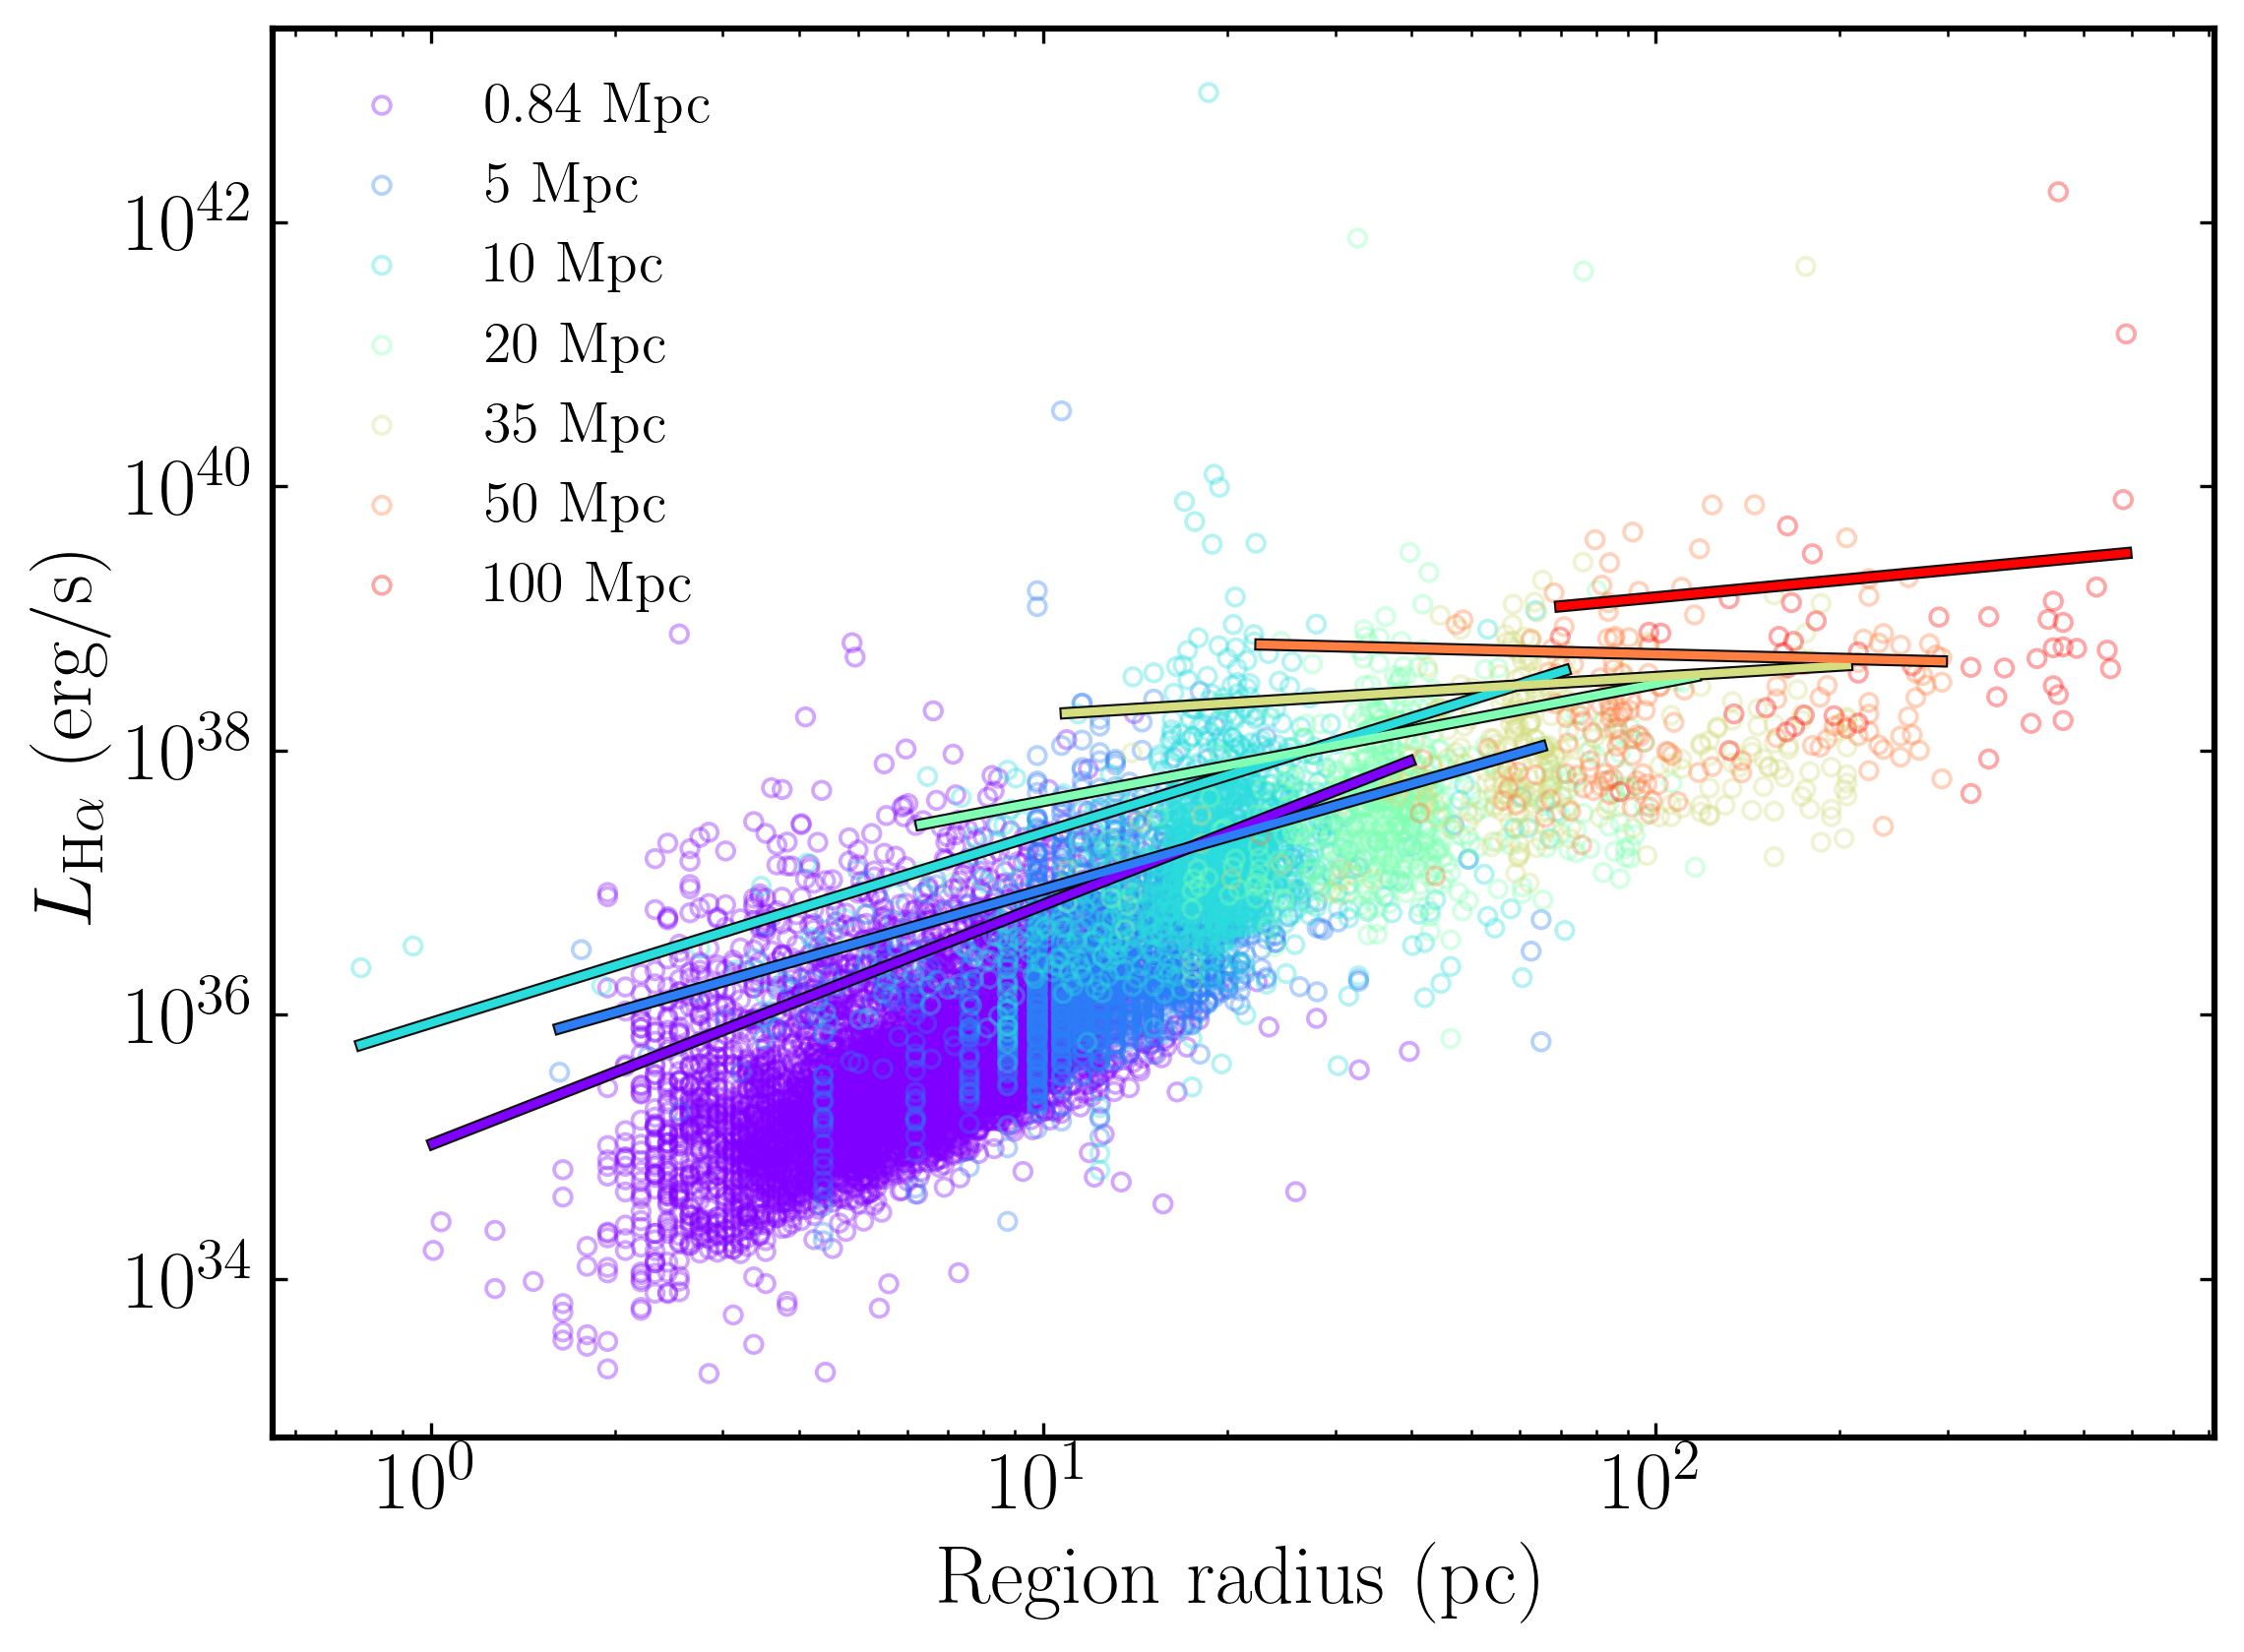

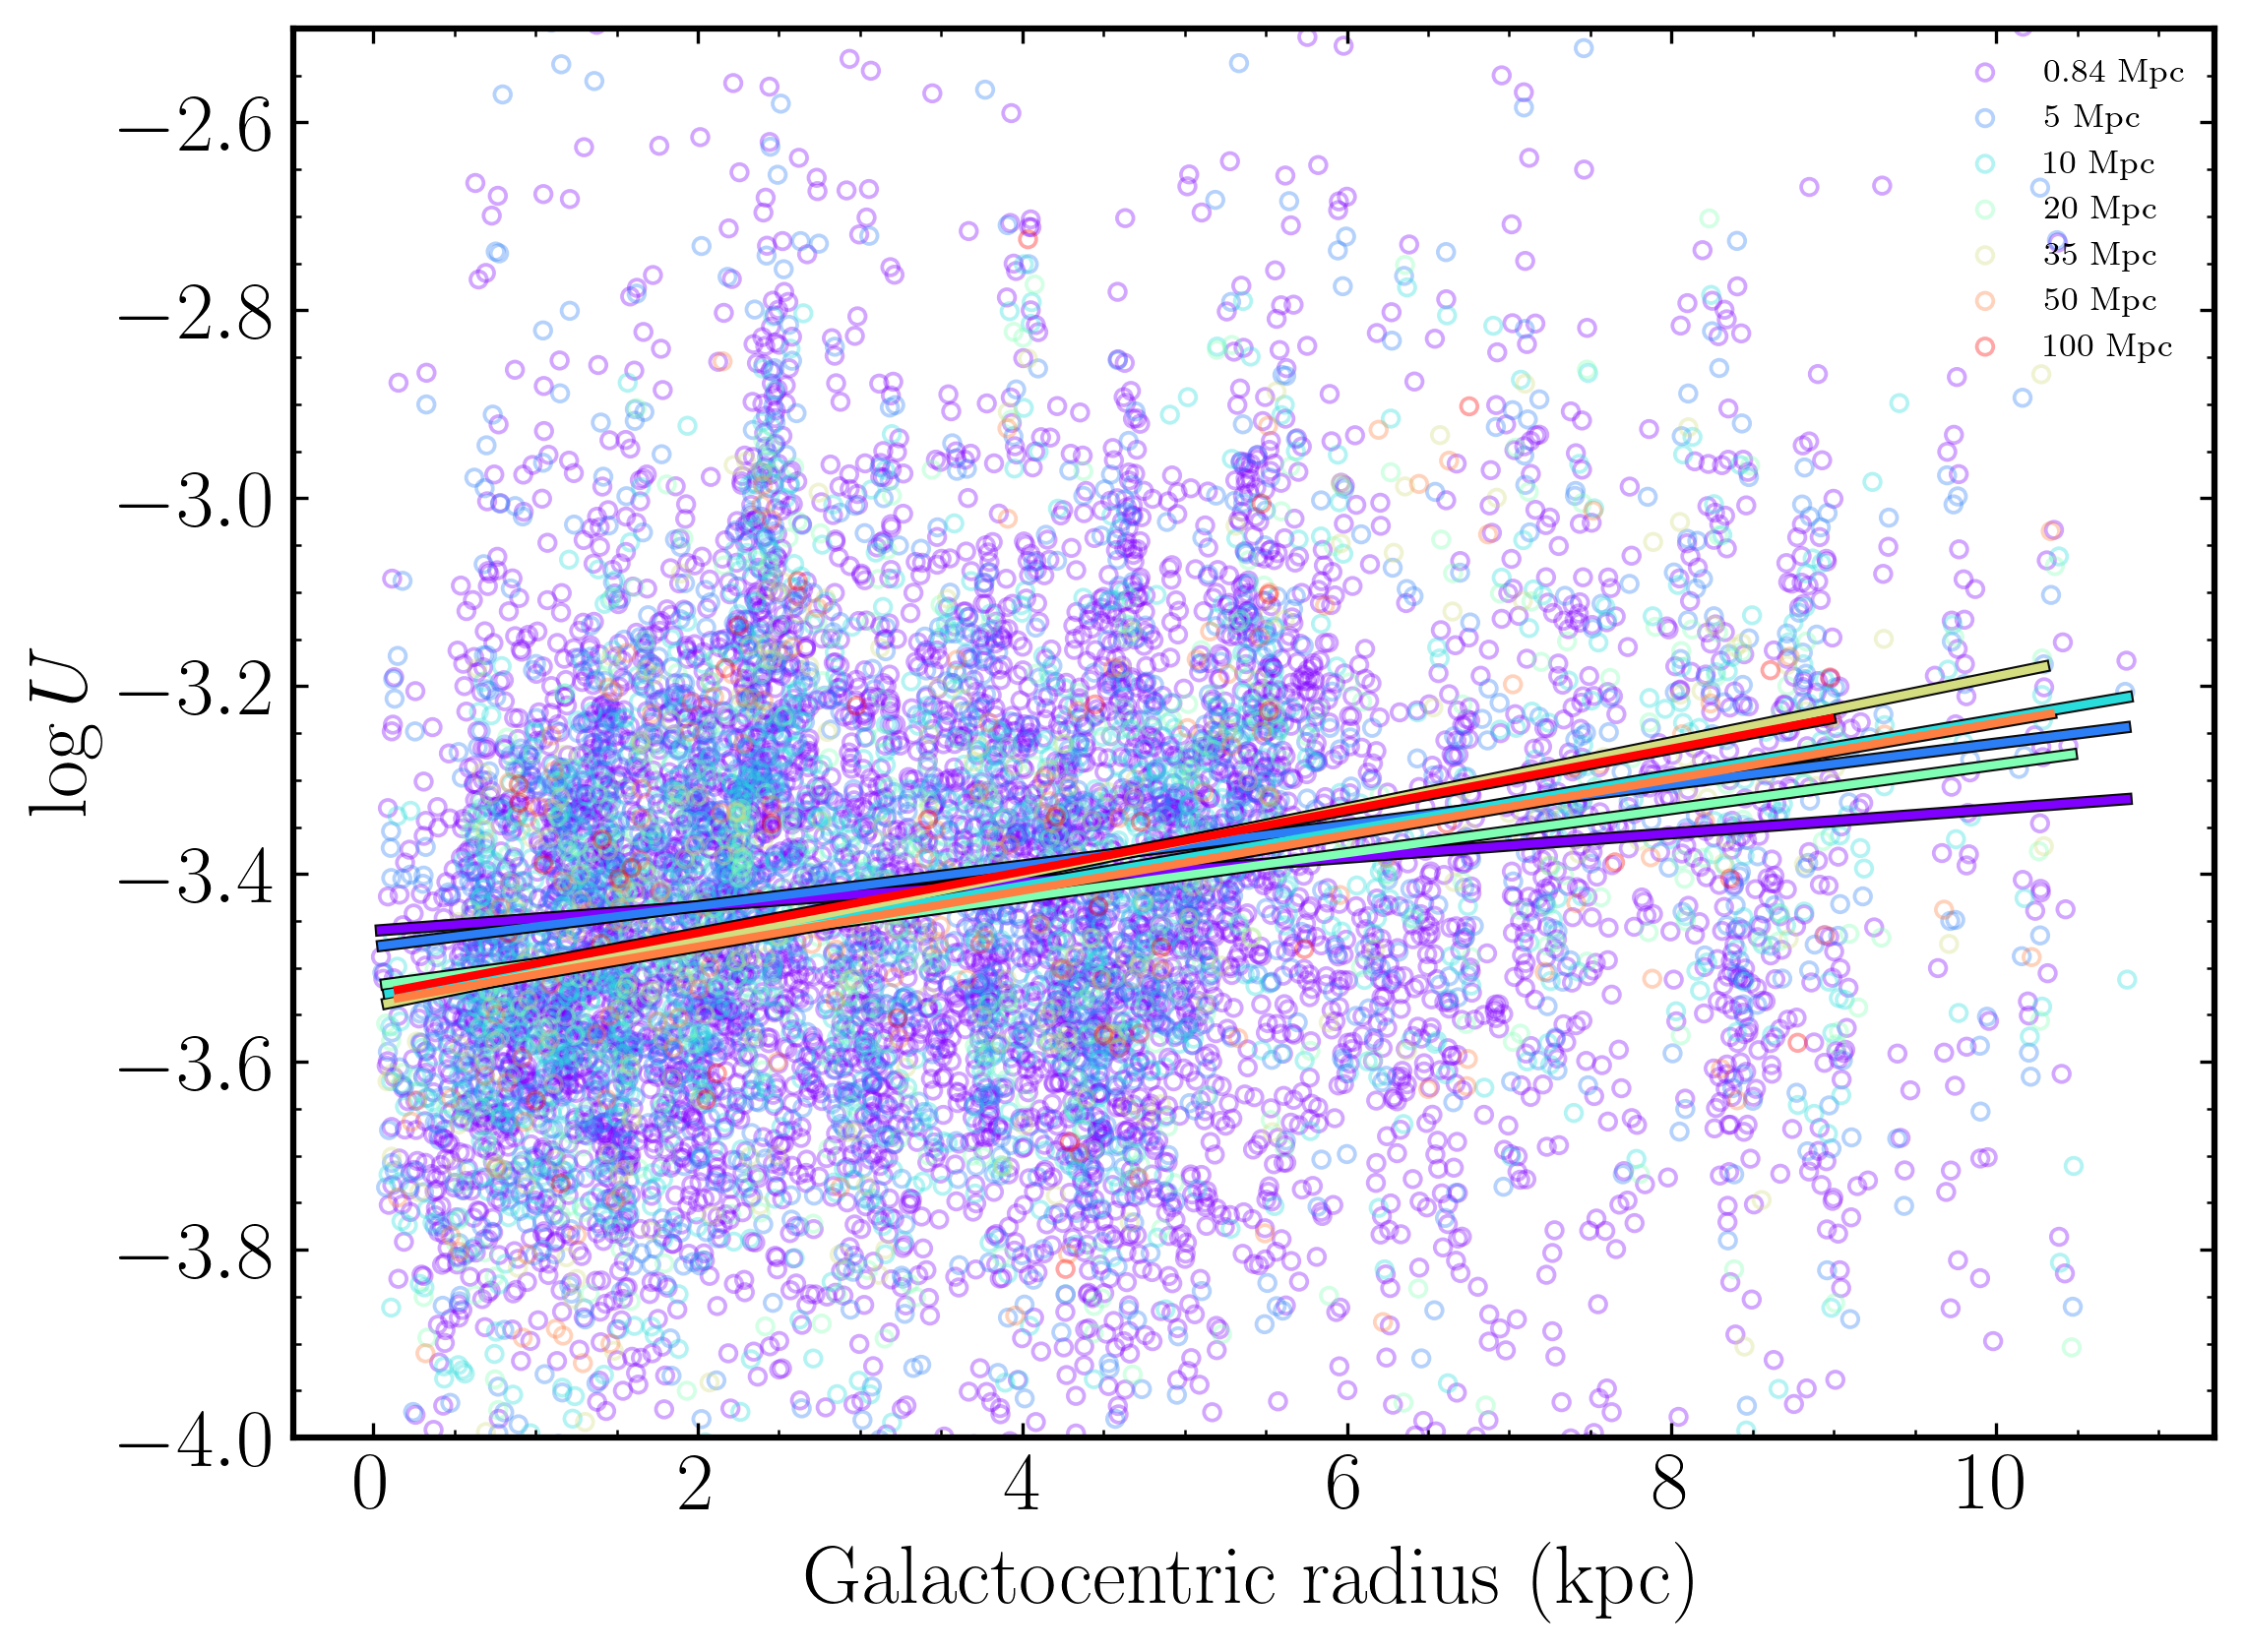

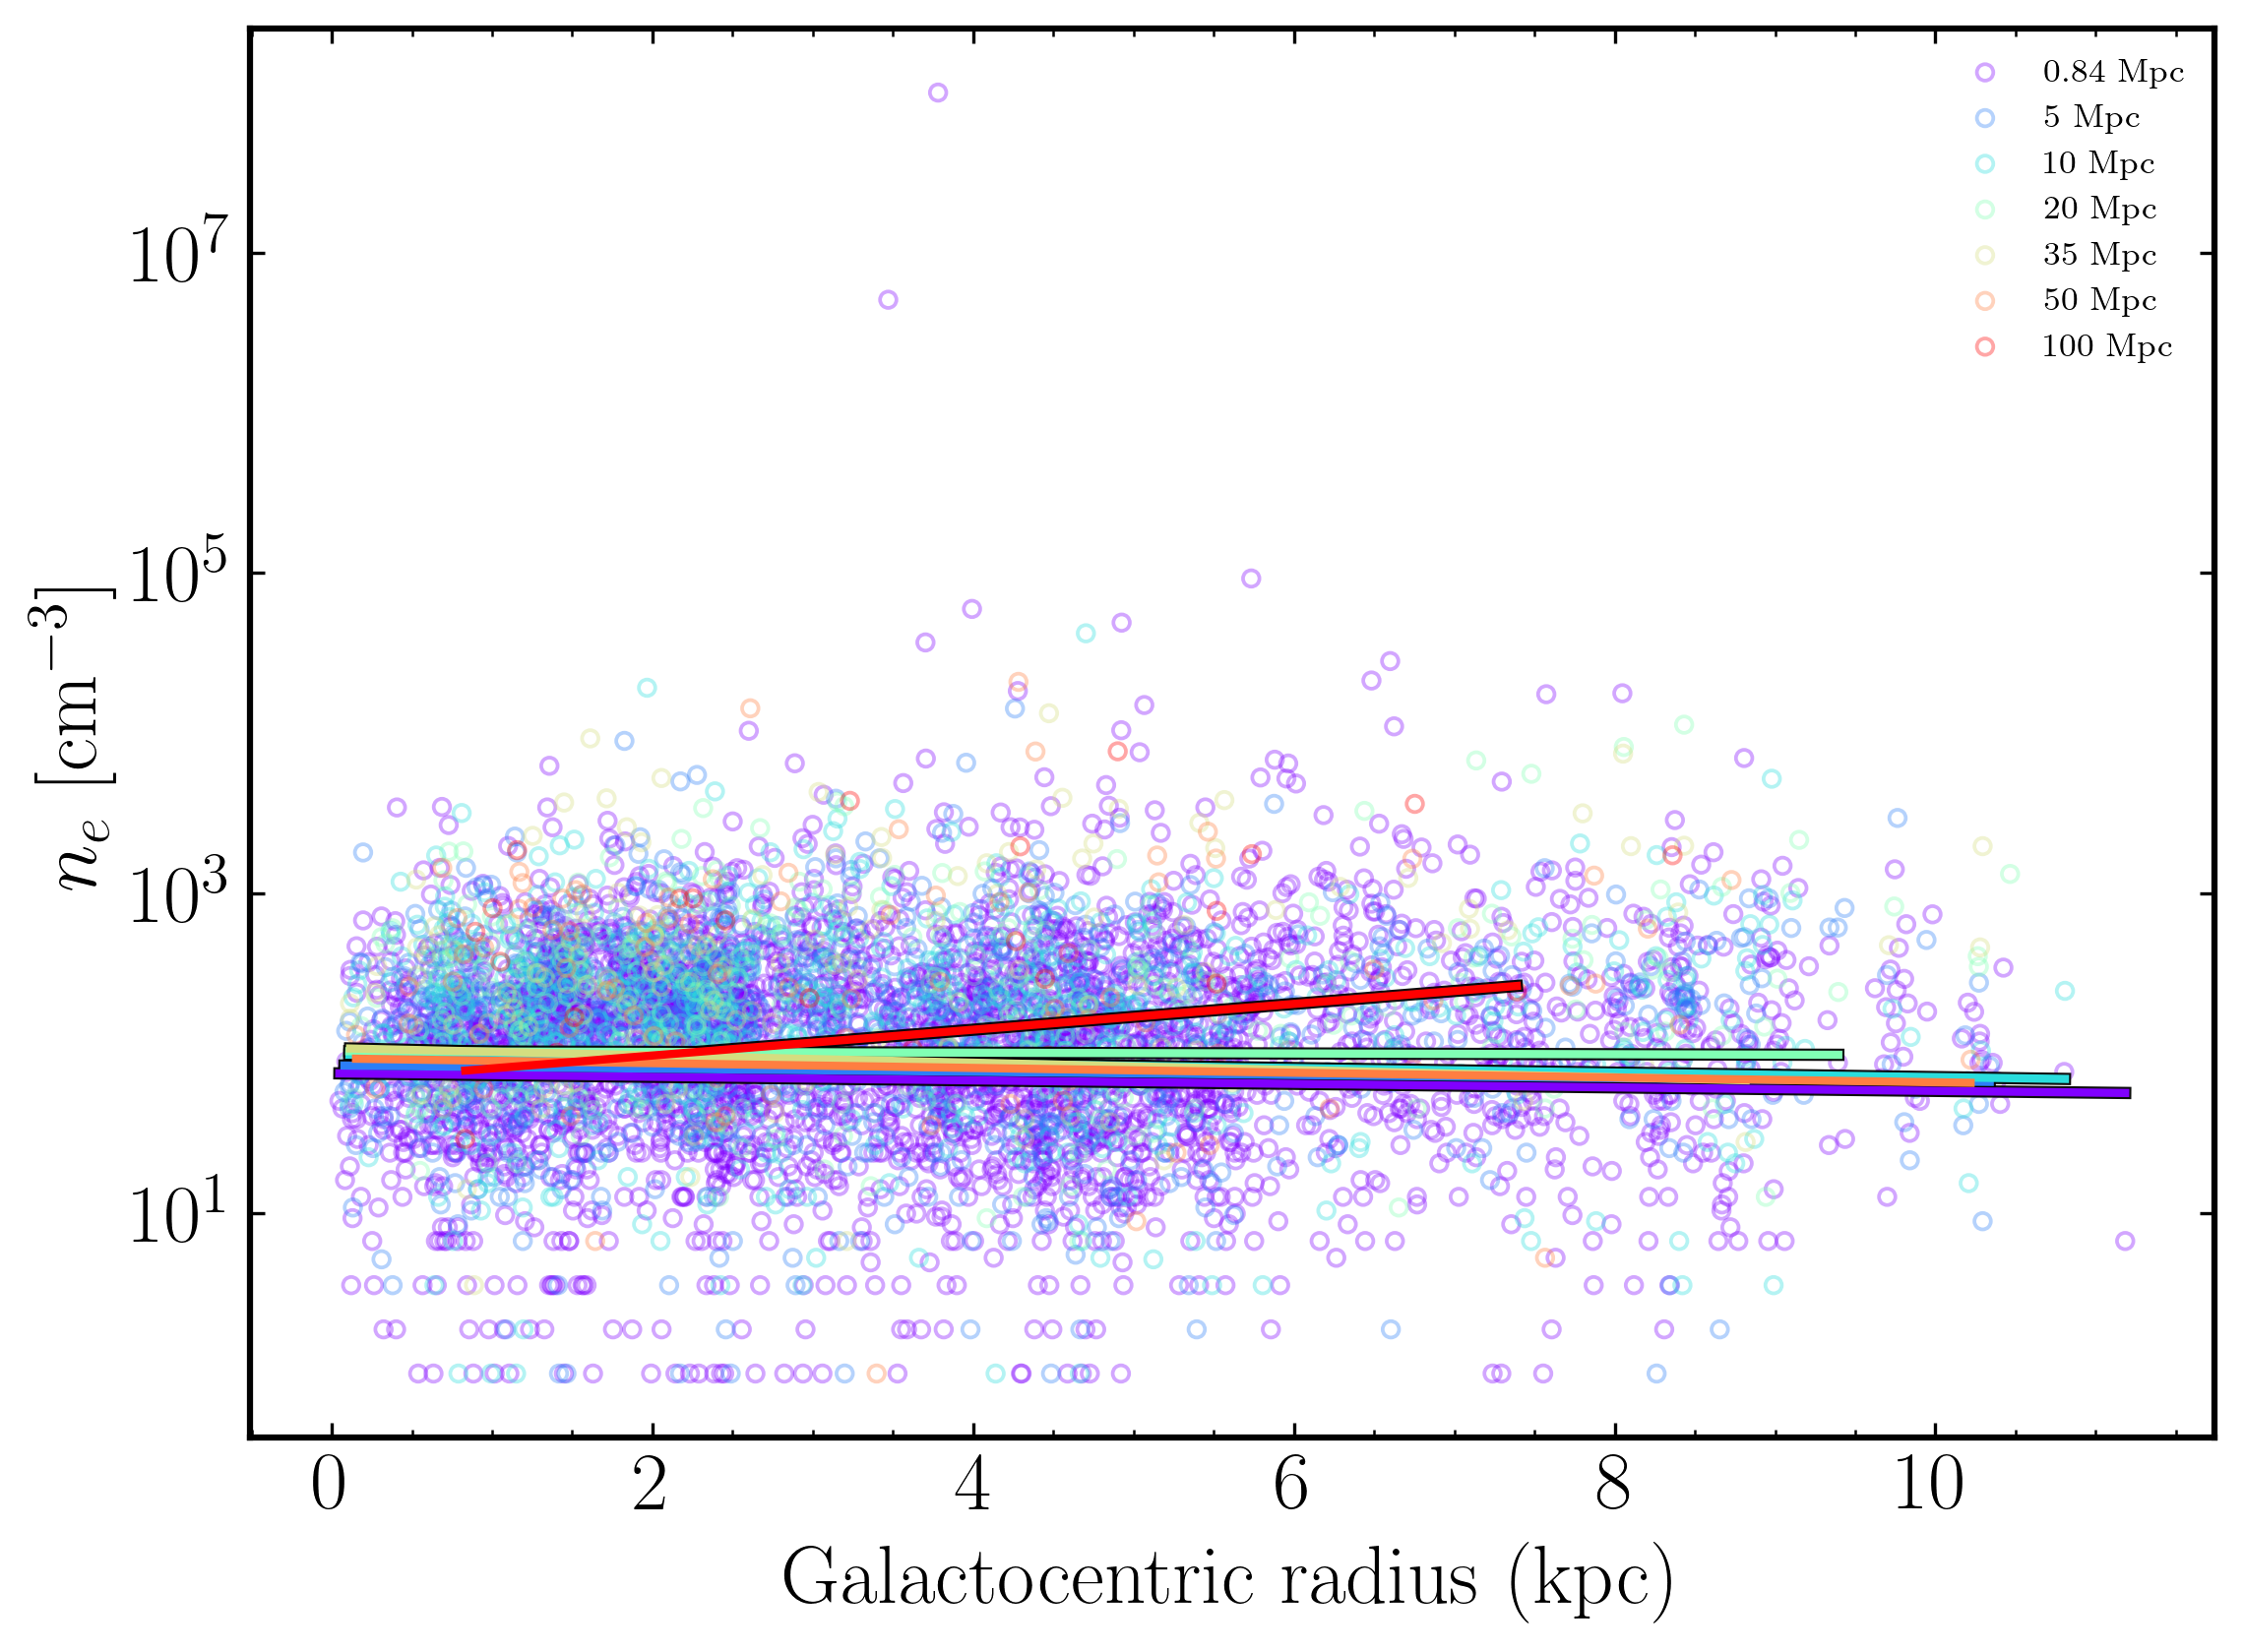

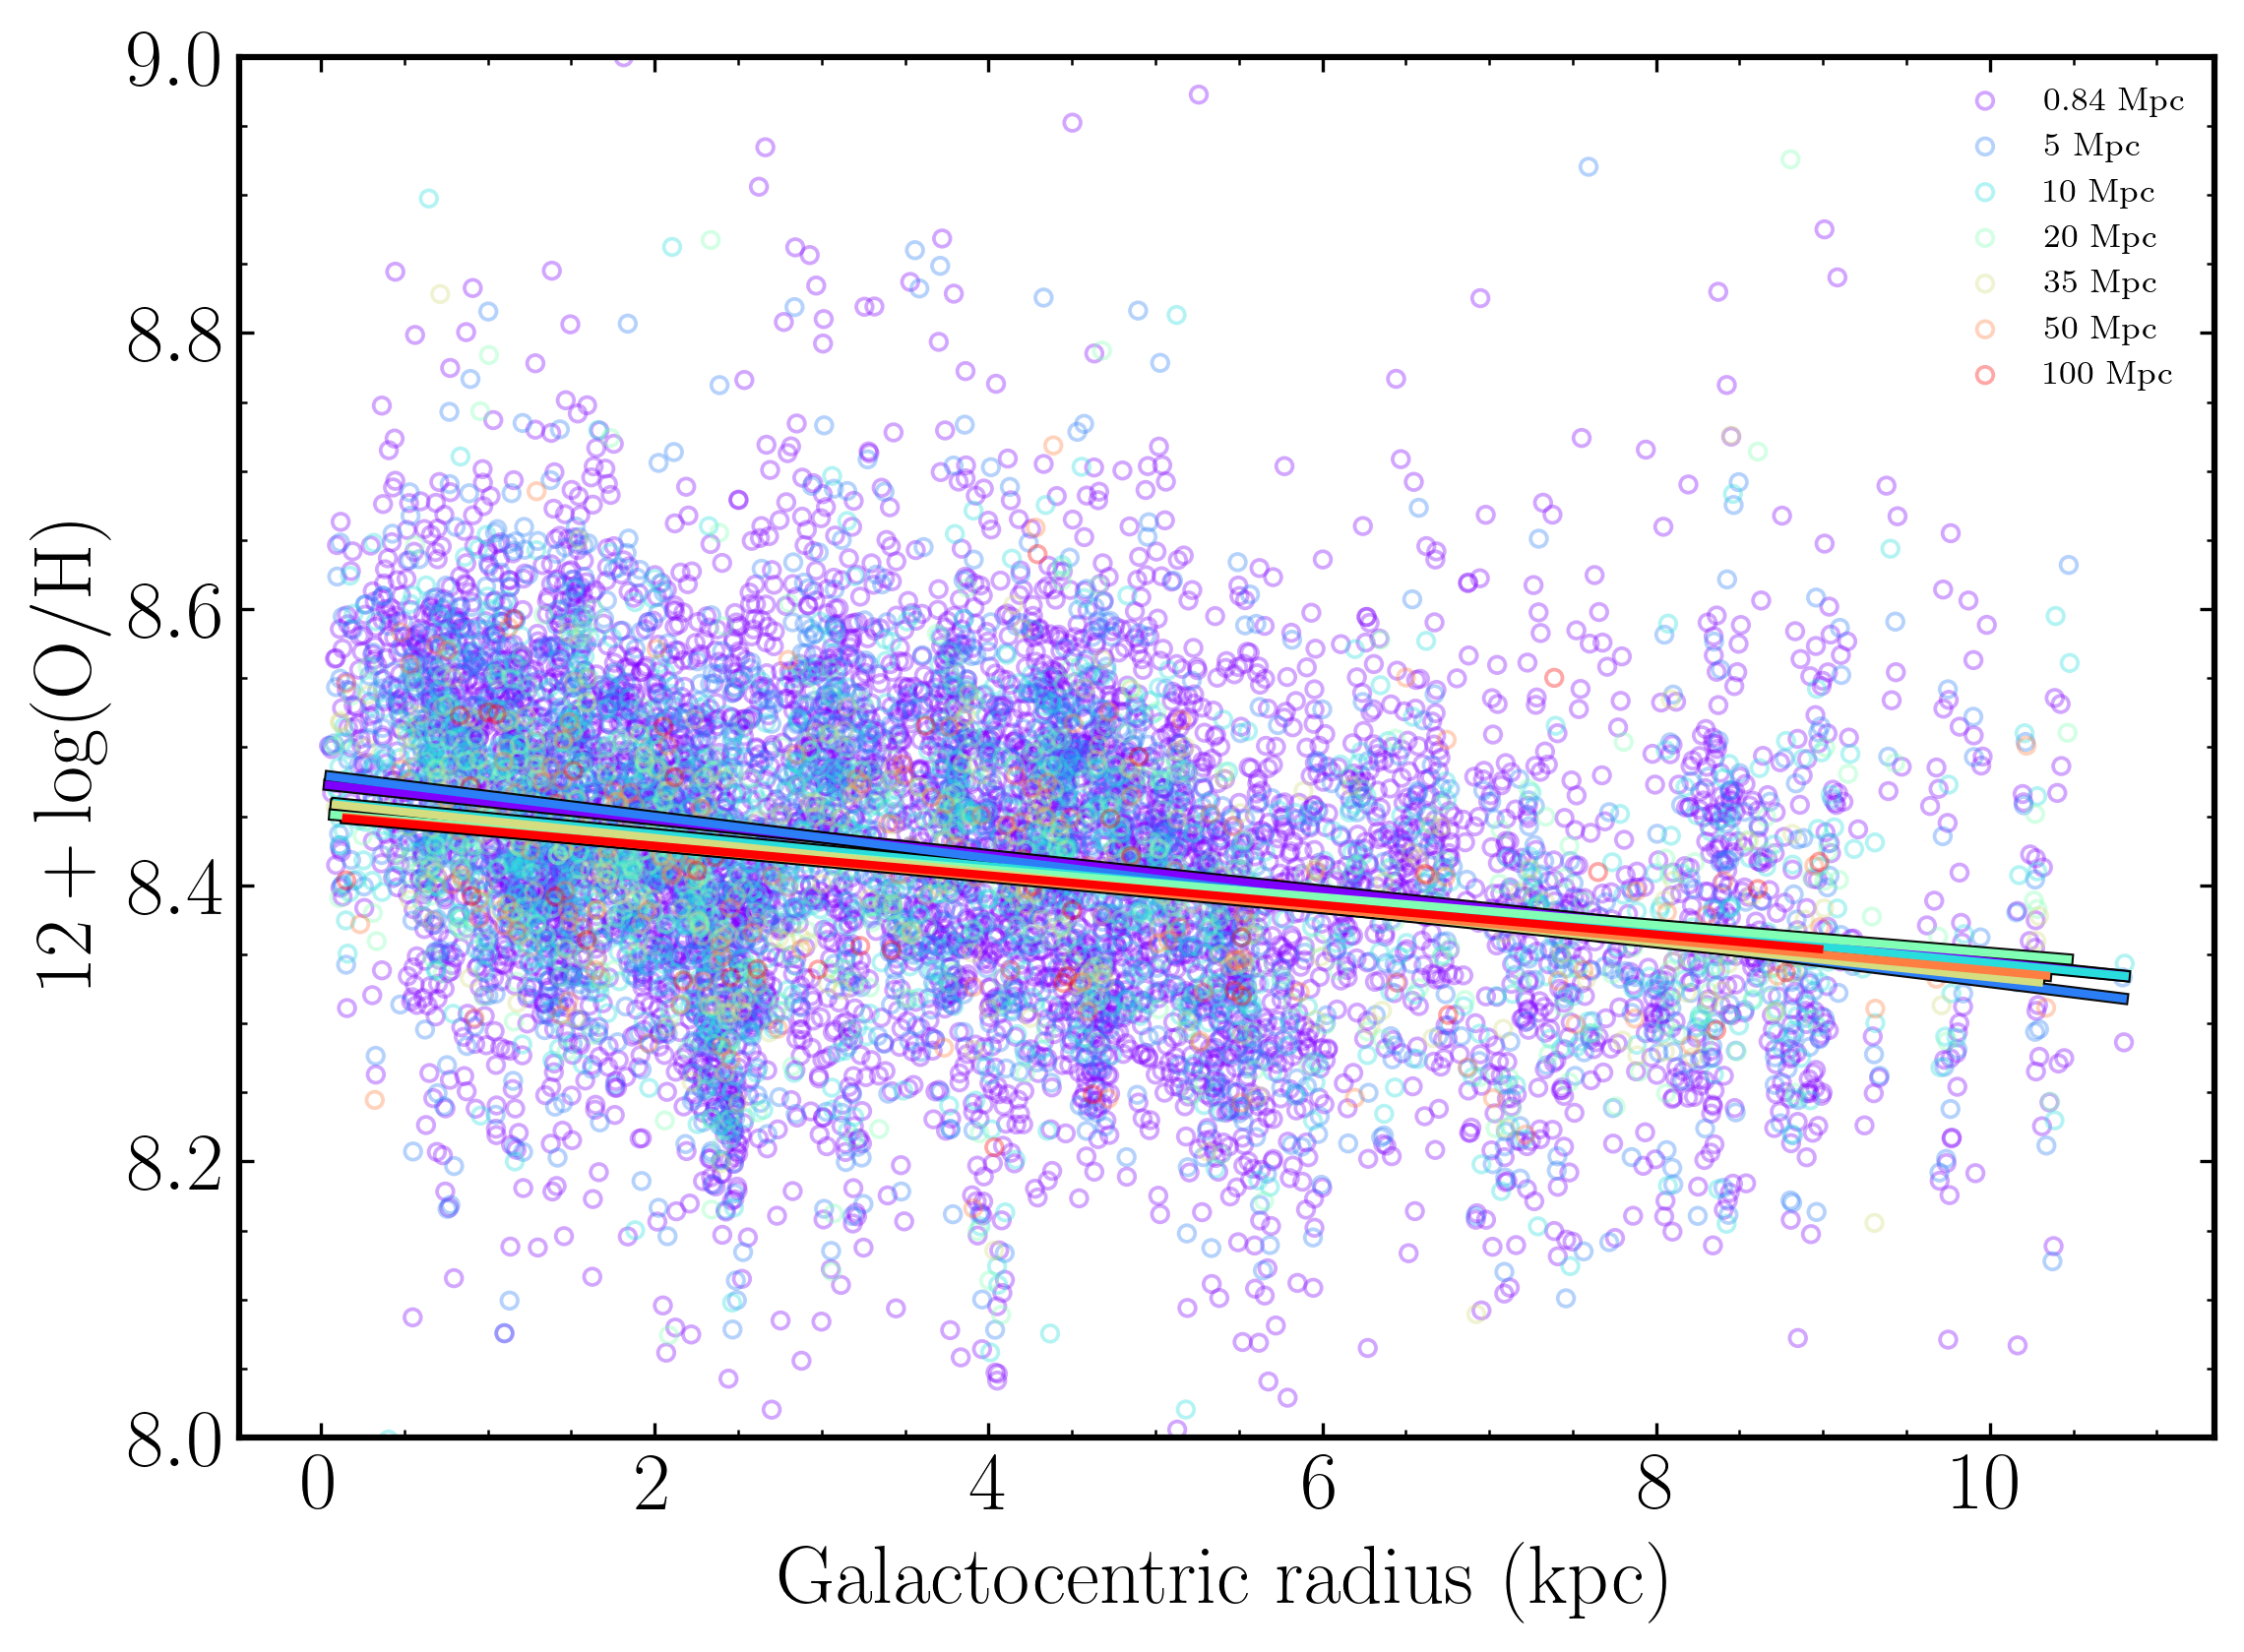

Wrote 255 commands to resolution_analysis_numbers.tex


In [10]:
luminosity_fig = plot_luminosity_vs_radius(catalogs_by_distance, include_fields=plot_fields, save=save_figures)
gradient_figs = plot_radial_gradients(catalogs_by_distance, include_fields=plot_fields, save=save_figures)
plt.show()

for fit_name, fit in resolution_fit_results.items():
    add_fit_values(resolution_values, resolution_formats, fit, fit_name)
    if 'chi2_red' in fit:
        command = f'{fit_name}ChiSquaredReduced'
        resolution_values[command] = fit['chi2_red']
        resolution_formats[command] = '.3f'

resolution_numbers_path = write_latex_commands(
    'resolution_analysis_numbers.tex',
    resolution_values,
    resolution_formats,
)
print(f'Wrote {len(resolution_values)} commands to {resolution_numbers_path}')


In [11]:
# plot the average spread in parameters as a function of distance, to show how the resolution degradation affects the precision of the measurements


## Terminal Build Stages

Build products in the terminal first:

```bash
python run_resolution_degradation_pipeline.py --stage degrade
python run_resolution_degradation_pipeline.py --stage peaks
python run_resolution_degradation_pipeline.py --stage regions
python run_resolution_degradation_pipeline.py --stage catalogs
```

Then come back here to load the saved outputs and make plots interactively.
